# VERIX vs CertCF on the synthetic 32D dataset

This notebook compares VERIX-derived counterfactuals and CertCF on the same
balanced queries, target classes, and classifier checkpoints. In addition to
validity, proximity, sparsity, and runtime, it reproduces the paper's
on-manifoldness and empirical robustness metrics. It
also applies the same post-hoc LiRPA certification procedure to both methods.

VERIX itself returns an explanation rather than an optimized counterfactual.
Here, the VERIX-derived counterfactual is the closest valid native solver
witness encountered during its feature traversal.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
for path in (ROOT, ROOT / 'src'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from notebooks.utils.verix_certcf import (
    completion_table,
    compute_synthetic32_diagnostics,
    load_synthetic32_results,
    method_summary,
    paired_query_table,
    paired_summary,
    summarize_empirical_robustness,
    summarize_quality_metrics,
)

CONFIG_PATH = ROOT / 'configs' / 'experiments' / 'verix_certcf_synthetic32.yaml'
RESULT_DIR = ROOT / 'results' / 'verix_certcf_synthetic32'
QUERIES_RAW, RUNNER_SUMMARY, MANIFEST = load_synthetic32_results(RESULT_DIR)
POINT_METRICS, ROBUSTNESS_CURVES, DIAGNOSTICS = compute_synthetic32_diagnostics(
    config_path=CONFIG_PATH,
    result_dir=RESULT_DIR,
    device='auto',
    certified=True,
)

METHOD_LABELS = {'verix': 'VERIX', 'certcf': 'CertCF'}
METHOD_ORDER = ['VERIX', 'CertCF']
PALETTE = {'VERIX': '#1f77b4', 'CertCF': '#d62728'}
sns.set_theme(style='whitegrid', context='notebook')

def quiet_boxplot(*args, **kwargs):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        return sns.boxplot(*args, **kwargs)

QUERIES = POINT_METRICS.assign(
    method_label=POINT_METRICS['method'].map(METHOD_LABELS)
)
ROBUSTNESS_CURVES = ROBUSTNESS_CURVES.assign(
    method_label=ROBUSTNESS_CURVES['method'].map(METHOD_LABELS)
)
print(
    f"Loaded {len(QUERIES)} method/query rows; diagnostics cache used "
    f"{DIAGNOSTICS['device']} and LiRPA-{DIAGNOSTICS['certified_lirpa_method']}."
)

/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/.venv/lib/python3.11/site-packages/auto_LiRPA/perturbations.py:199: RuntimeWarning: divide by zero encountered in scalar divide
  self.dual_norm = 1 if (norm == np.inf) else (np.float64(1.0) / (1 - 1.0 / self.norm))
/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/.venv/lib/python3.11/site-packages/auto_LiRPA/operators/linear.py:662: RuntimeWarning: divide by zero encountered in scalar divide
  dual_norm = np.float64(1.0) / (1 - 1.0 / norm)


Loaded 20 method/query rows; diagnostics cache used cuda and LiRPA-backward.


## 1. Benchmark completion

Partial architectures remain visible, but cross-architecture conclusions should
only be made once both methods have completed the same prepared queries.

In [2]:
COMPLETION = completion_table(QUERIES, MANIFEST)
display(COMPLETION)
if COMPLETION['complete'].all():
    display(Markdown(
        '**Benchmark complete:** both methods are available for every '
        'configured architecture.'
    ))
else:
    missing = COMPLETION.loc[
        ~COMPLETION['complete'], ['architecture_id', 'method']
    ]
    display(Markdown(
        f'**Partial benchmark:** {len(missing)} architecture/method '
        'combinations are still missing.'
    ))

,architecture_id,method,rows,unique_queries,expected_queries,complete
0,depth_01_width_016,verix,10,10,10,True
1,depth_01_width_016,certcf,10,10,10,True
2,depth_05_width_256,verix,0,0,10,False
3,depth_05_width_256,certcf,0,0,10,False


**Partial benchmark:** 2 architecture/method combinations are still missing.

## 2. Paper-aligned method-level comparison

Validity uses all paired-eligible queries. Distance, sparsity, LOF, and
robustness use successful counterfactuals. Empirical robustness is target-label
preservation averaged over the paper's Gaussian noise grid.

In [3]:
METHOD_SUMMARY = method_summary(QUERIES)
QUALITY_SUMMARY = summarize_quality_metrics(QUERIES)
EMPIRICAL_SUMMARY = summarize_empirical_robustness(ROBUSTNESS_CURVES)

for frame in (METHOD_SUMMARY, QUALITY_SUMMARY, EMPIRICAL_SUMMARY):
    frame['method'] = frame['method'].astype(str)

PAPER_TABLE = (
    METHOD_SUMMARY
    .merge(
        QUALITY_SUMMARY,
        on=['architecture_id', 'depth', 'width', 'parameter_count', 'method'],
        how='left',
        suffixes=('', '_quality'),
    )
    .merge(
        EMPIRICAL_SUMMARY,
        on=['architecture_id', 'method'],
        how='left',
    )
)
PAPER_COLUMNS = [
    'architecture_id', 'method', 'successful_queries', 'success_rate',
    'mean_l1', 'mean_l0', 'empirical_robustness_pct',
    'mean_log10_lof', 'mean_isolation_forest_score',
    'mean_certified_l1_radius', 'mean_certified_l2_radius',
    'mean_certified_linf_radius', 'mean_query_seconds',
    'offline_build_seconds',
]
display(PAPER_TABLE[PAPER_COLUMNS].style.format({
    'success_rate': '{:.1%}',
    'mean_l1': '{:.3f}',
    'mean_l0': '{:.2f}',
    'empirical_robustness_pct': '{:.1f}',
    'mean_log10_lof': '{:.4f}',
    'mean_isolation_forest_score': '{:.4f}',
    'mean_certified_l1_radius': '{:.5f}',
    'mean_certified_l2_radius': '{:.5f}',
    'mean_certified_linf_radius': '{:.5f}',
    'mean_query_seconds': '{:.4f}',
    'offline_build_seconds': '{:.3f}',
}))

,architecture_id,method,successful_queries,success_rate,mean_l1,mean_l0,empirical_robustness_pct,mean_log10_lof,mean_isolation_forest_score,mean_certified_l1_radius,mean_certified_l2_radius,mean_certified_linf_radius,mean_query_seconds,offline_build_seconds
0,depth_01_width_016,verix,10,100.0%,10.952,23.70,56.2,0.0621,-0.4548,0.00000,0.00000,0.00000,0.3797,0.000
1,depth_01_width_016,certcf,10,100.0%,23.796,20.20,97.8,0.0157,-0.4205,1.48727,0.60623,0.12943,0.1428,13.830


## 3. Paired query comparison

Only queries for which both methods return a valid counterfactual enter this
table. The ratio `certcf_over_verix_l1` is therefore a genuinely paired
comparison rather than a ratio of independently selected successful sets.

In [4]:
PAIRED = paired_query_table(QUERIES)
PAIRED_SUMMARY = paired_summary(PAIRED)
display(PAIRED_SUMMARY.style.format({
    'mean_certcf_over_verix_l1': '{:.3f}',
    'median_certcf_over_verix_l1': '{:.3f}',
    'mean_certcf_minus_verix_l1': '{:.3f}',
    'mean_certcf_minus_verix_l0': '{:.3f}',
    'mean_certcf_minus_verix_query_seconds': '{:.4f}',
}))

,architecture_id,depth,width,parameter_count,shared_successes,mean_certcf_over_verix_l1,median_certcf_over_verix_l1,mean_certcf_minus_verix_l1,mean_certcf_minus_verix_l0,mean_certcf_minus_verix_query_seconds
0,depth_01_width_016,1,16,562,10,2.340,2.013,12.844,-3.500,-0.2369


## 4. On-manifoldness

On-manifoldness follows both paper diagnostics: novelty LOF with $k=20$ and an
Isolation Forest with 200 trees, both fitted on the training split. For
$\log_{10}(\mathrm{LOF})$, lower is less outlying; for the Isolation Forest
score, higher is more inlying.

,architecture_id,method,n_success,mean_log10_lof,mean_negative_lof_score,mean_isolation_forest_score
0,depth_01_width_016,certcf,10,0.0157,-1.0377,-0.4205
1,depth_01_width_016,verix,10,0.0621,-1.1566,-0.4548


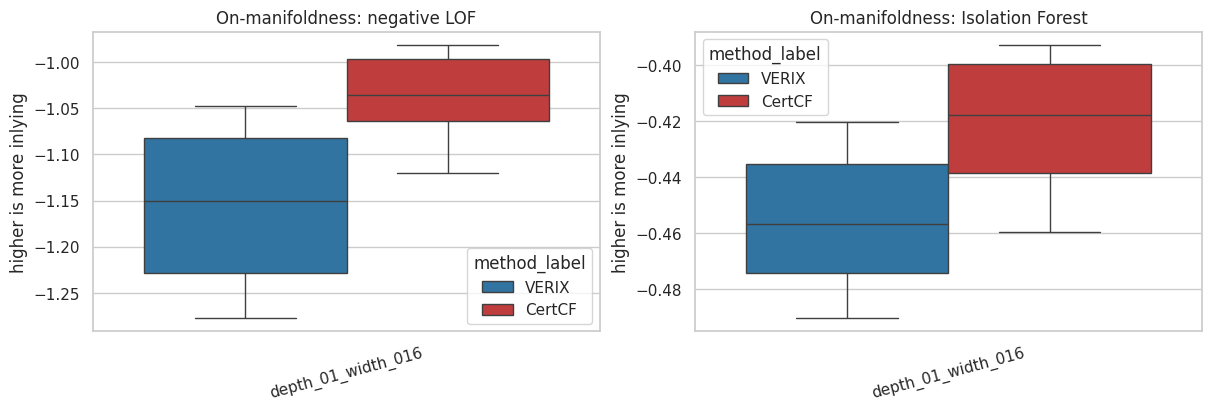

In [5]:
MANIFOLD_TABLE = QUALITY_SUMMARY[[
    'architecture_id', 'method', 'n_success',
    'mean_log10_lof', 'mean_negative_lof_score',
    'mean_isolation_forest_score',
]].copy()
display(MANIFOLD_TABLE.style.format({
    'mean_log10_lof': '{:.4f}',
    'mean_negative_lof_score': '{:.4f}',
    'mean_isolation_forest_score': '{:.4f}',
}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
plot_data = QUERIES[QUERIES['paired_eligible'] & QUERIES['success']].copy()
quiet_boxplot(
    data=plot_data, x='architecture_id', y='negative_lof_score',
    hue='method_label', hue_order=METHOD_ORDER, palette=PALETTE,
    ax=axes[0],
)
axes[0].set(title='On-manifoldness: negative LOF', xlabel='', ylabel='higher is more inlying')
axes[0].tick_params(axis='x', rotation=15)
quiet_boxplot(
    data=plot_data, x='architecture_id', y='isolation_forest_score',
    hue='method_label', hue_order=METHOD_ORDER, palette=PALETTE,
    ax=axes[1],
)
axes[1].set(title='On-manifoldness: Isolation Forest', xlabel='', ylabel='higher is more inlying')
axes[1].tick_params(axis='x', rotation=15)
plt.show()

## 5. Empirical robustness

For each successful counterfactual, 10 Gaussian perturbations are evaluated at
$\sigma\in\{0,0.01,0.03,0.05,0.1\}$ in standardized feature space, matching the
numerical part of the paper protocol. The same random perturbation directions
are used for VERIX and CertCF on each paired query.

,architecture_id,method,empirical_robustness_pct,all_perturbations_preserved_pct,robustness_grid_rows
0,depth_01_width_016,certcf,97.8,96.0,50
1,depth_01_width_016,verix,56.2,20.0,50


,architecture_id,method_label,sigma,target_preservation_pct,all_preserved_pct,n_queries
0,depth_01_width_016,CertCF,0.00,100.0,100.0,10
1,depth_01_width_016,CertCF,0.01,100.0,100.0,10
2,depth_01_width_016,CertCF,0.03,100.0,100.0,10
3,depth_01_width_016,CertCF,0.05,95.0,90.0,10
4,depth_01_width_016,CertCF,0.10,94.0,90.0,10
5,depth_01_width_016,VERIX,0.00,100.0,100.0,10
6,depth_01_width_016,VERIX,0.01,41.0,0.0,10
7,depth_01_width_016,VERIX,0.03,52.0,0.0,10
8,depth_01_width_016,VERIX,0.05,44.0,0.0,10
9,depth_01_width_016,VERIX,0.10,44.0,0.0,10


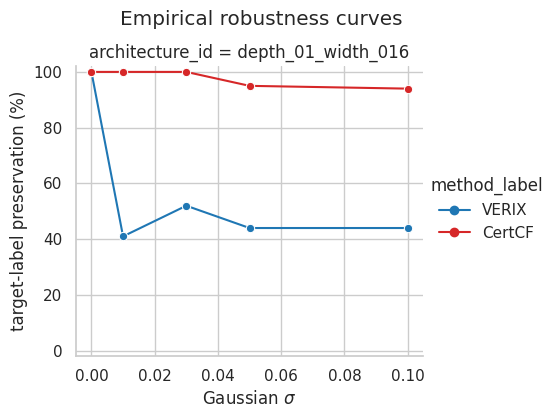

In [6]:
display(EMPIRICAL_SUMMARY.style.format({
    'empirical_robustness_pct': '{:.1f}',
    'all_perturbations_preserved_pct': '{:.1f}',
}))

ROBUSTNESS_BY_SIGMA = (
    ROBUSTNESS_CURVES
    .groupby(['architecture_id', 'method_label', 'sigma'], observed=True)
    .agg(
        target_preservation_pct=(
            'empirical_target_rate',
            lambda values: 100.0 * float(np.mean(values)),
        ),
        all_preserved_pct=(
            'empirical_all_preserved',
            lambda values: 100.0 * float(np.mean(values)),
        ),
        n_queries=('query_index', 'nunique'),
    )
    .reset_index()
)
display(ROBUSTNESS_BY_SIGMA)

g = sns.relplot(
    data=ROBUSTNESS_BY_SIGMA,
    x='sigma', y='target_preservation_pct',
    hue='method_label', hue_order=METHOD_ORDER, palette=PALETTE,
    col='architecture_id', kind='line', marker='o',
    height=4, aspect=1.15,
)
g.set_axis_labels(r'Gaussian $\sigma$', 'target-label preservation (%)')
g.set(ylim=(-2, 102))
g.figure.suptitle('Empirical robustness curves', y=1.04)
plt.show()

## 6. Post-hoc certified robustness

Both methods are evaluated with the same backward-LiRPA certification procedure.
The metrics are certified $L_1$, $L_2$, and $L_\infty$ target-class radii,
binary-searched independently up to $5.0$. A value at the cap is a lower bound,
not an exact radius. A reported zero
means that no positive radius was established at the configured resolution; it
does not prove that the mathematical robustness radius is exactly zero.

,architecture_id,method,n_success,mean_certified_l1_radius,median_certified_l1_radius,certified_l1_cap_fraction,mean_certified_l2_radius,median_certified_l2_radius,certified_l2_cap_fraction,mean_certified_linf_radius,median_certified_linf_radius,certified_linf_cap_fraction
0,depth_01_width_016,certcf,10,1.487274,1.586761,0.0%,0.606232,0.662689,0.0%,0.129425,0.142212,0.0%
1,depth_01_width_016,verix,10,0.000000,0.000000,0.0%,0.000000,0.000000,0.0%,0.000000,0.000000,0.0%


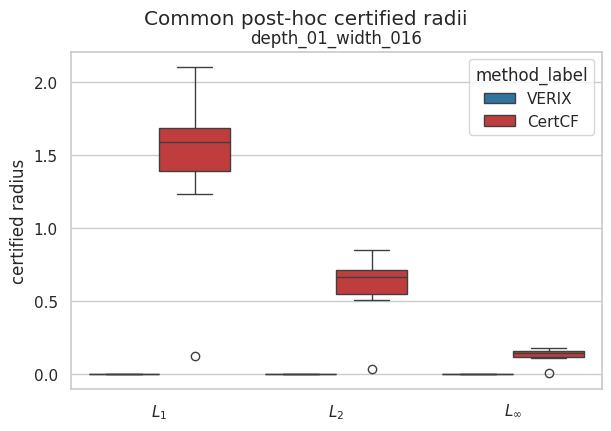

In [7]:
CERTIFIED_TABLE = QUALITY_SUMMARY[[
    'architecture_id', 'method', 'n_success',
    'mean_certified_l1_radius', 'median_certified_l1_radius',
    'certified_l1_cap_fraction',
    'mean_certified_l2_radius', 'median_certified_l2_radius',
    'certified_l2_cap_fraction',
    'mean_certified_linf_radius', 'median_certified_linf_radius',
    'certified_linf_cap_fraction',
]].copy()
display(CERTIFIED_TABLE.style.format({
    'mean_certified_l1_radius': '{:.6f}',
    'median_certified_l1_radius': '{:.6f}',
    'certified_l1_cap_fraction': '{:.1%}',
    'mean_certified_l2_radius': '{:.6f}',
    'median_certified_l2_radius': '{:.6f}',
    'certified_l2_cap_fraction': '{:.1%}',
    'mean_certified_linf_radius': '{:.6f}',
    'median_certified_linf_radius': '{:.6f}',
    'certified_linf_cap_fraction': '{:.1%}',
}))

CERTIFIED_LONG = plot_data.melt(
    id_vars=['architecture_id', 'method_label'],
    value_vars=[
        'certified_l1_radius', 'certified_l2_radius',
        'certified_linf_radius',
    ],
    var_name='norm', value_name='certified_radius',
)
CERTIFIED_LONG['norm'] = CERTIFIED_LONG['norm'].map({
    'certified_l1_radius': '$L_1$',
    'certified_l2_radius': '$L_2$',
    'certified_linf_radius': '$L_\\infty$',
})
architectures = sorted(CERTIFIED_LONG['architecture_id'].unique())
fig, axes = plt.subplots(
    1, len(architectures), figsize=(6 * len(architectures), 4),
    squeeze=False, constrained_layout=True,
)
for ax, architecture in zip(axes.flat, architectures):
    quiet_boxplot(
        data=CERTIFIED_LONG[CERTIFIED_LONG['architecture_id'] == architecture],
        x='norm', y='certified_radius', hue='method_label',
        hue_order=METHOD_ORDER, palette=PALETTE, ax=ax,
    )
    ax.set(title=architecture, xlabel='', ylabel='certified radius')
fig.suptitle('Common post-hoc certified radii', y=1.04)
plt.show()

## 7. Paired manifoldness and robustness differences

The following table preserves query pairing for LOF, Isolation Forest, and
the certified radii.

In [8]:
diagnostic_metrics = [
    'log10_lof', 'isolation_forest_score',
    'certified_l1_radius', 'certified_l2_radius',
    'certified_linf_radius',
]
shared = QUERIES[QUERIES['paired_eligible'] & QUERIES['success']]
DIAGNOSTIC_PAIRED = shared.pivot(
    index=['architecture_id', 'query_index'],
    columns='method',
    values=diagnostic_metrics,
)
DIAGNOSTIC_PAIRED.columns = [
    f'{metric}_{method}' for metric, method in DIAGNOSTIC_PAIRED.columns
]
DIAGNOSTIC_PAIRED = DIAGNOSTIC_PAIRED.dropna(
    subset=['log10_lof_verix', 'log10_lof_certcf']
).reset_index()
for metric in diagnostic_metrics:
    DIAGNOSTIC_PAIRED[f'certcf_minus_verix_{metric}'] = (
        DIAGNOSTIC_PAIRED[f'{metric}_certcf']
        - DIAGNOSTIC_PAIRED[f'{metric}_verix']
    )

PAIRED_DIAGNOSTIC_SUMMARY = (
    DIAGNOSTIC_PAIRED
    .groupby('architecture_id', observed=True)
    .agg(
        shared_queries=('query_index', 'count'),
        mean_certcf_minus_verix_log10_lof=(
            'certcf_minus_verix_log10_lof', 'mean'
        ),
        mean_certcf_minus_verix_iforest_score=(
            'certcf_minus_verix_isolation_forest_score', 'mean'
        ),
        mean_certcf_minus_verix_certified_l1_radius=(
            'certcf_minus_verix_certified_l1_radius', 'mean'
        ),
        mean_certcf_minus_verix_certified_l2_radius=(
            'certcf_minus_verix_certified_l2_radius', 'mean'
        ),
        mean_certcf_minus_verix_certified_linf_radius=(
            'certcf_minus_verix_certified_linf_radius', 'mean'
        ),
    )
    .reset_index()
)
display(PAIRED_DIAGNOSTIC_SUMMARY.style.format({
    'mean_certcf_minus_verix_log10_lof': '{:.4f}',
    'mean_certcf_minus_verix_iforest_score': '{:.4f}',
    'mean_certcf_minus_verix_certified_l1_radius': '{:.6f}',
    'mean_certcf_minus_verix_certified_l2_radius': '{:.6f}',
    'mean_certcf_minus_verix_certified_linf_radius': '{:.6f}',
}))

,architecture_id,shared_queries,mean_certcf_minus_verix_log10_lof,mean_certcf_minus_verix_iforest_score,mean_certcf_minus_verix_certified_l1_radius,mean_certcf_minus_verix_certified_l2_radius,mean_certcf_minus_verix_certified_linf_radius
0,depth_01_width_016,10,-0.0464,0.0343,1.487274,0.606232,0.129425


## 8. Distance and sparsity distributions

These distributions use the same successful-query set as the manifoldness and
robustness analyses.

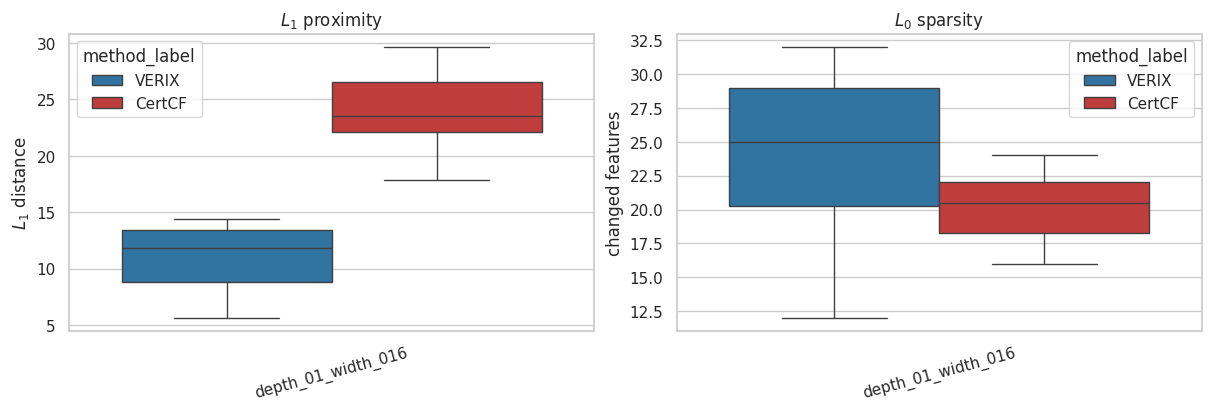

In [9]:
successful = QUERIES[QUERIES['paired_eligible'] & QUERIES['success']].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
quiet_boxplot(
    data=successful, x='architecture_id', y='l1_distance',
    hue='method_label', hue_order=METHOD_ORDER, palette=PALETTE, ax=axes[0],
)
axes[0].set(title=r'$L_1$ proximity', xlabel='', ylabel=r'$L_1$ distance')
axes[0].tick_params(axis='x', rotation=15)
quiet_boxplot(
    data=successful, x='architecture_id', y='l0_changed',
    hue='method_label', hue_order=METHOD_ORDER, palette=PALETTE, ax=axes[1],
)
axes[1].set(title=r'$L_0$ sparsity', xlabel='', ylabel='changed features')
axes[1].tick_params(axis='x', rotation=15)
plt.show()

## 9. Query time and offline construction

VERIX time includes sensitivity scoring and all formal feature checks. CertCF
online time excludes its one-time atlas construction, which is shown separately.

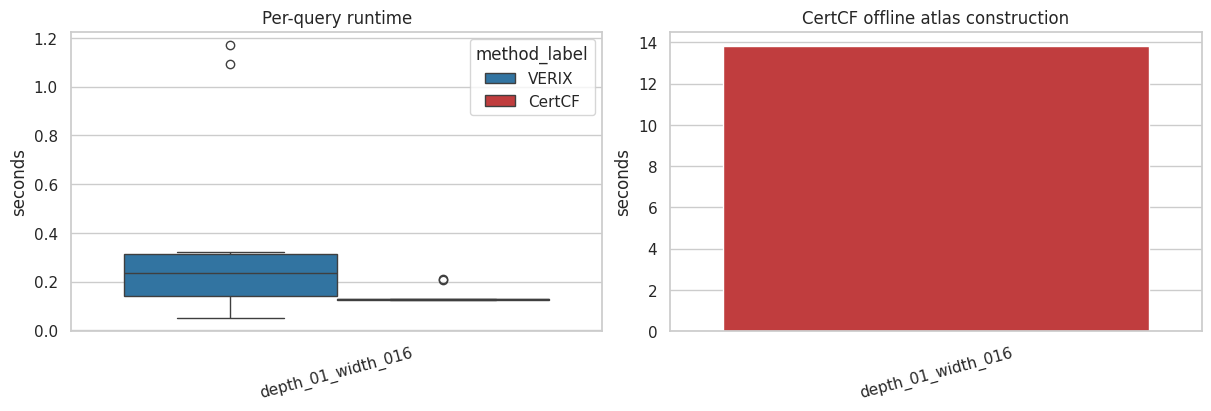

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
quiet_boxplot(
    data=QUERIES, x='architecture_id', y='runtime_seconds',
    hue='method_label', hue_order=METHOD_ORDER, palette=PALETTE, ax=axes[0],
)
axes[0].set(title='Per-query runtime', xlabel='', ylabel='seconds')
axes[0].tick_params(axis='x', rotation=15)

build = (
    QUERIES[QUERIES['method'] == 'certcf']
    .groupby('architecture_id', observed=True)['offline_build_seconds']
    .first()
    .reset_index()
)
sns.barplot(
    data=build, x='architecture_id', y='offline_build_seconds',
    color=PALETTE['CertCF'], ax=axes[1],
)
axes[1].set(title='CertCF offline atlas construction', xlabel='', ylabel='seconds')
axes[1].tick_params(axis='x', rotation=15)
plt.show()

## 10. Complete per-query paired table

This audit table combines proximity, sparsity, manifoldness, empirical
robustness, certified robustness, margins, and runtime.

In [11]:
ROBUSTNESS_PER_QUERY = (
    ROBUSTNESS_CURVES
    .groupby(['architecture_id', 'query_index', 'method'], observed=True)
    .agg(
        empirical_robustness_pct=(
            'empirical_target_rate',
            lambda values: 100.0 * float(np.mean(values)),
        )
    )
    .reset_index()
)
AUDIT = (
    QUERIES
    .merge(
        ROBUSTNESS_PER_QUERY,
        on=['architecture_id', 'query_index', 'method'],
        how='left',
    )
)
audit_metrics = [
    'l1_distance', 'l0_changed', 'log10_lof',
    'isolation_forest_score',
    'empirical_robustness_pct',
    'certified_l1_radius', 'certified_l2_radius',
    'certified_linf_radius',
    'runtime_seconds', 'target_margin',
]
AUDIT_PAIRED = AUDIT.pivot(
    index=['architecture_id', 'query_index'],
    columns='method',
    values=audit_metrics,
)
AUDIT_PAIRED.columns = [
    f'{metric}_{method}' for metric, method in AUDIT_PAIRED.columns
]
AUDIT_PAIRED = AUDIT_PAIRED.reset_index()
display(AUDIT_PAIRED.style.format(precision=4))

,architecture_id,query_index,l1_distance_certcf,l1_distance_verix,l0_changed_certcf,l0_changed_verix,log10_lof_certcf,log10_lof_verix,isolation_forest_score_certcf,isolation_forest_score_verix,empirical_robustness_pct_certcf,empirical_robustness_pct_verix,certified_l1_radius_certcf,certified_l1_radius_verix,certified_l2_radius_certcf,certified_l2_radius_verix,certified_linf_radius_certcf,certified_linf_radius_verix,runtime_seconds_certcf,runtime_seconds_verix,target_margin_certcf,target_margin_verix
0,depth_01_width_016,74,29.6335,13.8297,22.0000,30.0000,-0.0080,0.0879,-0.3946,-0.4778,100.0000,48.0000,1.7001,0.0000,0.7068,0.0000,0.1523,0.0000,0.1264,0.2122,4.2140,0.0000
1,depth_01_width_016,165,17.8563,11.7343,18.0000,25.0000,0.0271,0.0308,-0.4316,-0.4236,100.0000,44.0000,1.4883,0.0000,0.5536,0.0000,0.1227,0.0000,0.1264,0.1218,3.2645,0.0000
2,depth_01_width_016,229,23.7858,9.6415,22.0000,21.0000,0.0166,0.0426,-0.4060,-0.4577,100.0000,64.0000,1.6034,0.0000,0.6619,0.0000,0.1428,0.0000,0.1269,0.1364,5.2565,0.0000
3,depth_01_width_016,271,23.1378,12.2903,20.0000,25.0000,0.0255,0.0375,-0.4408,-0.4447,100.0000,50.0000,1.6238,0.0000,0.7141,0.0000,0.1538,0.0000,0.1263,1.1700,3.9105,0.0000
4,depth_01_width_016,471,27.7762,8.6168,22.0000,20.0000,0.0141,0.0788,-0.4122,-0.4902,100.0000,54.0000,1.2338,0.0000,0.5072,0.0000,0.1077,0.0000,0.2063,0.2814,3.0517,0.0000
5,depth_01_width_016,786,26.8993,14.3161,19.0000,31.0000,-0.0014,0.0943,-0.4233,-0.4700,100.0000,50.0000,2.1021,0.0000,0.8463,0.0000,0.1782,0.0000,0.1259,0.2562,4.0929,0.0000
6,depth_01_width_016,877,25.3410,14.4245,24.0000,32.0000,-0.0042,0.0331,-0.3928,-0.4323,78.0000,46.0000,0.1184,0.0000,0.0336,0.0000,0.0064,0.0000,0.1278,0.3227,0.1096,0.0000
7,depth_01_width_016,929,21.8141,11.8658,16.0000,26.0000,0.0494,0.1061,-0.4472,-0.4759,100.0000,68.0000,2.0755,0.0000,0.8282,0.0000,0.1736,0.0000,0.1261,1.0924,4.7052,0.0000
8,depth_01_width_016,956,23.2563,5.6619,21.0000,12.0000,0.0388,0.0900,-0.4596,-0.4559,100.0000,76.0000,1.3571,0.0000,0.5472,0.0000,0.1151,0.0000,0.2096,0.0517,3.6670,0.0000
9,depth_01_width_016,958,18.4574,7.1414,18.0000,15.0000,-0.0011,0.0201,-0.3974,-0.4203,100.0000,62.0000,1.5701,0.0000,0.6635,0.0000,0.1416,0.0000,0.1262,0.1525,3.4630,0.0000


## 11. Interpretation and caveats

- LOF and Isolation Forest measure how outlying a point is relative to the
  full training distribution and are reported as complementary diagnostics.
- Empirical robustness is a finite random test and is not a formal guarantee.
  The post-hoc LiRPA radius is the formal lower bound reported here.
- The synthetic dataset has only continuous features. Consequently, the
  categorical-flip part of the paper's robustness protocol does not apply, and
  domain feasibility should not be interpreted as real-world actionability.
- CertCF query time excludes atlas construction. The offline and online costs
  must remain separately reported.
- VERIX is an explanation method, not a proximity optimizer. This experiment
  evaluates solver witnesses derived from its traversal.
- Results use one dataset and one training seed. The current 10-query endpoint
  run validates the protocol but is not a high-powered statistical comparison.

In [12]:
for architecture in sorted(QUERIES['architecture_id'].unique()):
    paper_rows = PAPER_TABLE[PAPER_TABLE['architecture_id'] == architecture]
    if set(paper_rows['method']) != {'verix', 'certcf'}:
        continue
    verix = paper_rows[paper_rows['method'] == 'verix'].iloc[0]
    certcf = paper_rows[paper_rows['method'] == 'certcf'].iloc[0]
    summary = (
        fr"**{architecture}.** On {int(verix['successful_queries'])} shared "
        fr"successful queries, mean $\log_{{10}}(\mathrm{{LOF}})$ is "
        fr"{verix['mean_log10_lof']:.4f} for VERIX and "
        fr"{certcf['mean_log10_lof']:.4f} for CertCF. Empirical target preservation is "
        fr"{verix['empirical_robustness_pct']:.1f}% versus "
        fr"{certcf['empirical_robustness_pct']:.1f}%, while the mean certified "
        fr"$(L_1,L_2,L_\infty)$ radii are "
        fr"({verix['mean_certified_l1_radius']:.6f}, "
        fr"{verix['mean_certified_l2_radius']:.6f}, "
        fr"{verix['mean_certified_linf_radius']:.6f}) versus "
        fr"({certcf['mean_certified_l1_radius']:.6f}, "
        fr"{certcf['mean_certified_l2_radius']:.6f}, "
        fr"{certcf['mean_certified_linf_radius']:.6f})."
    )
    display(Markdown(summary))

**depth_01_width_016.** On 10 shared successful queries, mean $\log_{10}(\mathrm{LOF})$ is 0.0621 for VERIX and 0.0157 for CertCF. Empirical target preservation is 56.2% versus 97.8%, while the mean certified $(L_1,L_2,L_\infty)$ radii are (0.000000, 0.000000, 0.000000) versus (1.487274, 0.606232, 0.129425).